In [131]:
# libraries

import polars as pl 
import sys
sys.path.append('../src')
from kaggle_m5_xgboost_optuna.etl import *
import polars as pl
import xgboost as xgb
import numpy as np
import optuna
import math
import statistics as stat

from lets_plot import *
from lets_plot.mapping import as_discrete
from sklearn import model_selection
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import plotly
import plotly.figure_factory as ff

# Canonical WRMSE used across the notebook
def wrmse(y_true, y_pred):
    """Weighted RMSE with weights 1..n (canonical function for the notebook)."""
    yt = np.ravel(y_true)
    yp = np.ravel(y_pred)
    n = len(yt)
    if n == 0:
        return float('nan')
    w = np.arange(1, n + 1).astype(float)
    return math.sqrt(np.sum(w * (yt - yp) ** 2) / np.sum(w))


In [132]:
# Demo: use the pipeline module from src and save models under the package models/ directory
import os
import sys
import numpy as np
# Make the local 'src' folder importable in notebooks (works from project root)
sys.path.insert(0, os.path.abspath('src'))
from kaggle_m5_xgboost_optuna.pipeline import TrendResidualsEnsemble
from joblib import load
from sklearn.metrics import mean_squared_error
import math

# This cell is defensive: it will try to find X_train/Y_train and fall back to train_set_clean/validation_set_clean
# If none of these exist, it will raise a helpful error telling you which cells to run first.
def _to_numpy_1d(obj):
    if hasattr(obj, 'to_pandas'):
        arr = obj.to_pandas().values.ravel()
    else:
        arr = np.ravel(obj)
    return arr.astype(np.float32)

# Resolve training and validation inputs
if 'X_train' in globals() and 'Y_train' in globals():
    X_tr_src = X_train
    y_tr_src = Y_train
elif 'train_set_clean' in globals():
    # build from cleaned train_set_clean if available (polars)
    X_tr_src = train_set_clean.select(feature_cols)
    y_tr_src = train_set_clean.select('sales_plus_28')
else:
    raise RuntimeError('Demo: X_train/Y_train not found and train_set_clean not available. Run the data preparation / sampling cells first.')

if 'X_validation' in globals() and 'Y_validation' in globals():
    X_val_src = X_validation
    y_val_src = Y_validation
elif 'validation_set_clean' in globals():
    X_val_src = validation_set_clean.select(feature_cols)
    y_val_src = validation_set_clean.select('sales_plus_28')
else:
    # allow train-only demo (no early stopping) by setting validation to None
    X_val_src = None
    y_val_src = None

# Convert to numpy / pandas as needed for the pipeline
if hasattr(X_tr_src, 'to_pandas'):
    X_tr = X_tr_src.to_pandas().astype(np.float32)
else:
    X_tr = np.asarray(X_tr_src, dtype=np.float32)
y_tr = _to_numpy_1d(y_tr_src)

if X_val_src is not None:
    if hasattr(X_val_src, 'to_pandas'):
        X_val = X_val_src.to_pandas().astype(np.float32)
    else:
        X_val = np.asarray(X_val_src, dtype=np.float32)
    y_val = _to_numpy_1d(y_val_src)
else:
    X_val = None
    y_val = None

# Create models directory inside the package folder (robust in notebook)
pkg_root = os.path.abspath(os.path.join('src', 'kaggle_m5_xgboost_optuna'))
models_dir = os.path.join(pkg_root, 'models')
os.makedirs(models_dir, exist_ok=True)

print('Using models dir:', models_dir)

# Instantiate and fit the pipeline (small n_estimators by default to be fast)
pipe = TrendResidualsEnsemble(xgb_params={'objective':'reg:squarederror','n_estimators':100,'eta':0.05,'max_depth':4,'tree_method':'hist'})
if X_val is not None:
    pipe.fit(X_tr, y_tr, eval_set=(X_val, y_val))
else:
    pipe.fit(X_tr, y_tr)

# Save and reload to verify persistence
pipe_path = os.path.join(models_dir, 'trend_residuals_pipeline.joblib')
pipe.save(pipe_path)
print('Saved pipeline to', pipe_path)

loaded = TrendResidualsEnsemble.load(pipe_path)
print('Loaded pipeline from disk; running a quick predict on validation set (first 10 rows)')
if X_val is not None:
    preds = loaded.predict(X_val[:10])
    print('Sample predictions:', preds[:10])
    if y_val is not None:
        print('Validation RMSE (first 10 rows):', math.sqrt(mean_squared_error(y_val[:10], preds[:10])))
else:
    # run a tiny prediction on the training set to validate behavior
    preds = loaded.predict(X_tr[:10])
    print('Sample predictions on training rows:', preds[:10])

Using models dir: /Users/felixguex/kaggle_m5_xgboost_optuna/notebooks/src/kaggle_m5_xgboost_optuna/models
[0]	validation_0-rmse:3.61216
[1]	validation_0-rmse:3.61651
[2]	validation_0-rmse:3.62204
[3]	validation_0-rmse:3.62600
[4]	validation_0-rmse:3.62922
[5]	validation_0-rmse:3.62945
[6]	validation_0-rmse:3.62992
[7]	validation_0-rmse:3.63185
[8]	validation_0-rmse:3.63738
[9]	validation_0-rmse:3.63765
[10]	validation_0-rmse:3.63800
[1]	validation_0-rmse:3.61651
[2]	validation_0-rmse:3.62204
[3]	validation_0-rmse:3.62600
[4]	validation_0-rmse:3.62922
[5]	validation_0-rmse:3.62945
[6]	validation_0-rmse:3.62992
[7]	validation_0-rmse:3.63185
[8]	validation_0-rmse:3.63738
[9]	validation_0-rmse:3.63765
[10]	validation_0-rmse:3.63800
[11]	validation_0-rmse:3.63704
[12]	validation_0-rmse:3.63986
[13]	validation_0-rmse:3.64003
[14]	validation_0-rmse:3.64295
[15]	validation_0-rmse:3.64353
[16]	validation_0-rmse:3.64376
[17]	validation_0-rmse:3.64468
[18]	validation_0-rmse:3.64831
[19]	validatio

In [133]:
# Quick run-mode configuration: 'baseline' uses small samples for fast iteration, 'full' uses full datasets (careful!).
RUN_MODE = 'baseline'  # choose 'baseline' or 'full'
BASELINE_TRAIN = 50_000   # number of rows to use in baseline train
BASELINE_VALID = 12_000   # number of rows to use in baseline valid

print(f"RUN_MODE={RUN_MODE}; baseline_train={BASELINE_TRAIN}, baseline_valid={BASELINE_VALID}")

# Helper to decide sample sizes using estimate_max_rows if needed
def pick_sample_sizes():
    if RUN_MODE == 'full':
        return None, None
    # If estimate_max_rows is available later, you can integrate it; for now use constants
    return BASELINE_TRAIN, BASELINE_VALID


RUN_MODE=baseline; baseline_train=50000, baseline_valid=12000


In [134]:
# create polars dataframes for my data 
import polars as pl

calendar_pl = pl.read_csv('../data/raw/calendar.csv')
sales_train_evaluation_pl = pl.read_csv('../data/raw/sales_train_evaluation.csv')
sales_train_validation_pl = pl.read_csv('../data/raw/sales_train_validation.csv')
sell_prices_pl = pl.read_csv('../data/raw/sell_prices.csv')
sample_submission_pl = pl.read_csv('../data/raw/sample_submission.csv')
print("Polars DataFrames created.")
print("Calendar Polars DataFrame : ")
print(calendar_pl.head())
print ( "-"* 80)
print("Some basic properties :")
print('shape of the data : ', calendar_pl.shape)
print('columns of the data : ', calendar_pl.columns)
print('data types : ', calendar_pl.dtypes)
print('number of missing values : ')
print(calendar_pl.null_count())
print ( "="* 80)
print("Sales Train Evaluation Polars DataFrame : ")
print(sales_train_evaluation_pl.head())
print ( "-"* 80)
print("Some basic properties :")                
print('shape of the data : ', sales_train_evaluation_pl.shape)
print('columns of the data : ', sales_train_evaluation_pl.columns)
print('data types : ', sales_train_evaluation_pl.dtypes)
print('number of missing values : ')
print(sales_train_evaluation_pl.null_count())
print ( "="* 80)


Polars DataFrames created.
Calendar Polars DataFrame : 
shape: (5, 14)
┌────────────┬──────────┬───────────┬──────┬───┬──────────────┬─────────┬─────────┬─────────┐
│ date       ┆ wm_yr_wk ┆ weekday   ┆ wday ┆ … ┆ event_type_2 ┆ snap_CA ┆ snap_TX ┆ snap_WI │
│ ---        ┆ ---      ┆ ---       ┆ ---  ┆   ┆ ---          ┆ ---     ┆ ---     ┆ ---     │
│ str        ┆ i64      ┆ str       ┆ i64  ┆   ┆ str          ┆ i64     ┆ i64     ┆ i64     │
╞════════════╪══════════╪═══════════╪══════╪═══╪══════════════╪═════════╪═════════╪═════════╡
│ 2011-01-29 ┆ 11101    ┆ Saturday  ┆ 1    ┆ … ┆ null         ┆ 0       ┆ 0       ┆ 0       │
│ 2011-01-30 ┆ 11101    ┆ Sunday    ┆ 2    ┆ … ┆ null         ┆ 0       ┆ 0       ┆ 0       │
│ 2011-01-31 ┆ 11101    ┆ Monday    ┆ 3    ┆ … ┆ null         ┆ 0       ┆ 0       ┆ 0       │
│ 2011-02-01 ┆ 11101    ┆ Tuesday   ┆ 4    ┆ … ┆ null         ┆ 1       ┆ 1       ┆ 0       │
│ 2011-02-02 ┆ 11101    ┆ Wednesday ┆ 5    ┆ … ┆ null         ┆ 1       ┆ 0       ┆

In [135]:
# Process sales_train_evaluation_pl with the same steps as sales_train_validation_pl
# (unchanged cell content retained)

df_long_eval = sales_train_evaluation_pl.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=[col for col in sales_train_evaluation_pl.columns if col.startswith('d_')],
    variable_name='day',
    value_name='sales'
)

df_long_eval = df_long_eval.with_columns([
    pl.col('sales').shift(1).over('id').alias('lag_1'),
    pl.col('sales').shift(2).over('id').alias('lag_2'),
    pl.col('sales').shift(3).over('id').alias('lag_3'),
    pl.col('sales').shift(4).over('id').alias('lag_4'),
    pl.col('sales').shift(5).over('id').alias('lag_5'),
    pl.col('sales').shift(6).over('id').alias('lag_6'),
    pl.col('sales').shift(7).over('id').alias('lag_7'),
    pl.col('sales').shift(14).over('id').alias('lag_14'),
    pl.col('sales').shift(21).over('id').alias('lag_21'),
    pl.col('sales').shift(28).over('id').alias('lag_28'),
    pl.col('sales').rolling_mean(7).over('id').alias('rolling_mean_7'),
    pl.col('sales').rolling_mean(14).over('id').alias('rolling_mean_14'),
    pl.col('sales').rolling_mean(28).over('id').alias('rolling_mean_28'),
    pl.col('sales').rolling_mean(56).over('id').alias('rolling_mean_56')
])

# Join calendar data
calendar_pl = calendar_pl.with_columns([pl.col('d').alias('day')])
df_long_eval = df_long_eval.join(calendar_pl, on='day', how='left')

# Join price data
sell_prices_pl = sell_prices_pl.with_columns([
    pl.col('store_id').cast(pl.Categorical),
    pl.col('item_id').cast(pl.Categorical),
    pl.col('wm_yr_wk').cast(pl.Categorical)
])
df_long_eval = df_long_eval.with_columns([
    pl.col('store_id').cast(pl.Categorical),
    pl.col('item_id').cast(pl.Categorical),
    pl.col('wm_yr_wk').cast(pl.Categorical),
])
df_long_eval = df_long_eval.join(sell_prices_pl, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Add target variable (sales_plus_28)
df_long_eval = df_long_eval.with_columns([
    pl.col('sales').shift(-28).over('id').alias('sales_plus_28')
])

# Drop rows with nulls in features and target
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
    'lag_14', 'lag_21', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_mean_56'
]
selected_cols = feature_cols + ['sales_plus_28']
df_long_eval_clean = df_long_eval.select(selected_cols)

df_long_eval_clean = df_long_eval_clean.drop_nulls(subset=feature_cols + ['sales_plus_28'])


/var/folders/wf/j018ss495xl6mz1qb3wsb7rr0000gn/T/ipykernel_3103/856348929.py:4: DeprecationWarning:

`DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`



In [136]:
# Process sales_train_validation_pl with the same steps as sales_train_evaluation_pl
df_long_val = sales_train_validation_pl.melt(
    id_vars=['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],
    value_vars=[col for col in sales_train_validation_pl.columns if col.startswith('d_')],
    variable_name='day',
    value_name='sales'
)

df_long_val = df_long_val.with_columns([
    pl.col('sales').shift(1).over('id').alias('lag_1'),
    pl.col('sales').shift(2).over('id').alias('lag_2'),
    pl.col('sales').shift(3).over('id').alias('lag_3'),
    pl.col('sales').shift(4).over('id').alias('lag_4'),
    pl.col('sales').shift(5).over('id').alias('lag_5'),
    pl.col('sales').shift(6).over('id').alias('lag_6'),
    pl.col('sales').shift(7).over('id').alias('lag_7'),
    pl.col('sales').shift(14).over('id').alias('lag_14'),
    pl.col('sales').shift(21).over('id').alias('lag_21'),
    pl.col('sales').shift(28).over('id').alias('lag_28'),
    pl.col('sales').rolling_mean(7).over('id').alias('rolling_mean_7'),
    pl.col('sales').rolling_mean(14).over('id').alias('rolling_mean_14'),
    pl.col('sales').rolling_mean(28).over('id').alias('rolling_mean_28'),
    pl.col('sales').rolling_mean(56).over('id').alias('rolling_mean_56')
])

# Join calendar data
calendar_pl = calendar_pl.with_columns([pl.col('d').alias('day')])
df_long_val = df_long_val.join(calendar_pl, on='day', how='left')

# Join price data
sell_prices_pl = sell_prices_pl.with_columns([
    pl.col('store_id').cast(pl.Categorical),
    pl.col('item_id').cast(pl.Categorical),
    pl.col('wm_yr_wk').cast(pl.Categorical)
])
df_long_val = df_long_val.with_columns([
    pl.col('store_id').cast(pl.Categorical),
    pl.col('item_id').cast(pl.Categorical),
    pl.col('wm_yr_wk').cast(pl.Categorical)
])
df_long_val = df_long_val.join(sell_prices_pl, on=['store_id', 'item_id', 'wm_yr_wk'], how='left')

# Add target variable (sales_plus_28)
df_long_val = df_long_val.with_columns([
    pl.col('sales').shift(-28).over('id').alias('sales_plus_28')
])

# Drop rows with nulls in features and target
feature_cols = [
    'lag_1', 'lag_2', 'lag_3', 'lag_4', 'lag_5', 'lag_6', 'lag_7',
    'lag_14', 'lag_21', 'lag_28',
    'rolling_mean_7', 'rolling_mean_14', 'rolling_mean_28', 'rolling_mean_56'
]
selected_cols = feature_cols + ['sales_plus_28']

df_long_val_clean = df_long_val.select(selected_cols)

df_long_val_clean = df_long_val_clean.drop_nulls(subset=feature_cols + ['sales_plus_28'])





/var/folders/wf/j018ss495xl6mz1qb3wsb7rr0000gn/T/ipykernel_3103/459811586.py:2: DeprecationWarning:

`DataFrame.melt` is deprecated; use `DataFrame.unpivot` instead, with `index` instead of `id_vars` and `on` instead of `value_vars`



In [137]:
# Use RUN_MODE to control whether we sample for a quick baseline or use the full dataset
if RUN_MODE == 'full':
    train_set_clean = df_long_eval_clean
    validation_set_clean = df_long_val_clean
else:
    SAMPLE_TRAIN = min(BASELINE_TRAIN, df_long_eval_clean.height)
    SAMPLE_VALID = min(BASELINE_VALID, df_long_val_clean.height)
    train_set_clean = df_long_eval_clean.sample(n=SAMPLE_TRAIN)
    validation_set_clean = df_long_val_clean.sample(n=SAMPLE_VALID)

print('size of the dataframes : ')
print('x_train = ', len(train_set_clean))
print('X_validation = ', len(validation_set_clean))

# Select features/targets
X_train = train_set_clean.select(feature_cols)
X_validation = validation_set_clean.select(feature_cols)
Y_train = train_set_clean.select('sales_plus_28')
Y_validation = validation_set_clean.select('sales_plus_28')
print('sampling completed')

# training baseline: simple linear regression
from sklearn.linear_model import LinearRegression
print('conversion to pandas')
# convert small-ish sample to pandas for sklearn
if hasattr(X_train, 'to_pandas'):
    X_train = X_train.to_pandas()
if hasattr(Y_train, 'to_pandas'):
    y_train = Y_train.to_pandas().values.ravel()
else:
    y_train = Y_train.values.ravel()

print('creating the model')
model = LinearRegression()
print('fitting the model')
model.fit(X_train, y_train)

# Ensure X_validation is converted to pandas before prediction
if hasattr(X_validation, 'to_pandas'):
    X_validation_pd = X_validation.to_pandas()
else:
    X_validation_pd = X_validation

# Baseline predictions
y_pred = model.predict(X_validation_pd)


size of the dataframes : 
x_train =  50000
X_validation =  12000
sampling completed
conversion to pandas
creating the model
fitting the model


In [138]:
# Estimate safe sample size for XGBoost based on available memory (run after X_train/X_validation are defined)
import psutil
import numpy as np

def estimate_max_rows(X, memory_fraction=0.5, bytes_per_float=8):
    """
    Estimate the maximum number of rows that can fit in memory for XGBoost training.
    Args:
        X: Feature DataFrame (pandas or polars)
        memory_fraction: Fraction of available RAM to use (default 0.5)
        bytes_per_float: Number of bytes per float (default 8 for float64)
    Returns:
        max_rows: Estimated maximum number of rows
    """
    if hasattr(X, 'to_pandas'):
        X_pd = X.to_pandas()
    else:
        X_pd = X
    n_features = X_pd.shape[1]
    available_mem = psutil.virtual_memory().available * memory_fraction
    max_rows = int(available_mem // (n_features * bytes_per_float))
    return max_rows

max_rows_train = estimate_max_rows(X_train)
max_rows_valid = estimate_max_rows(X_validation)
print(f"Estimated max train rows: {max_rows_train}")
print(f"Estimated max validation rows: {max_rows_valid}")

Estimated max train rows: 14157750
Estimated max validation rows: 14161481


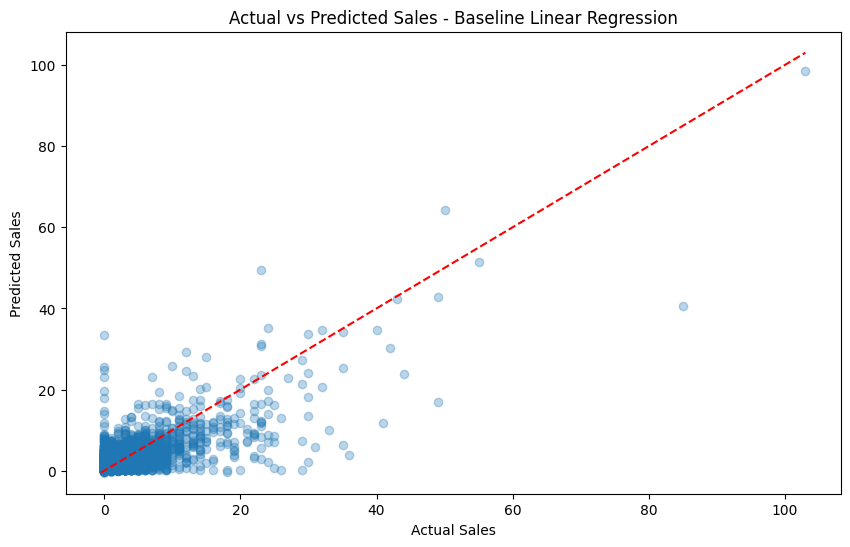

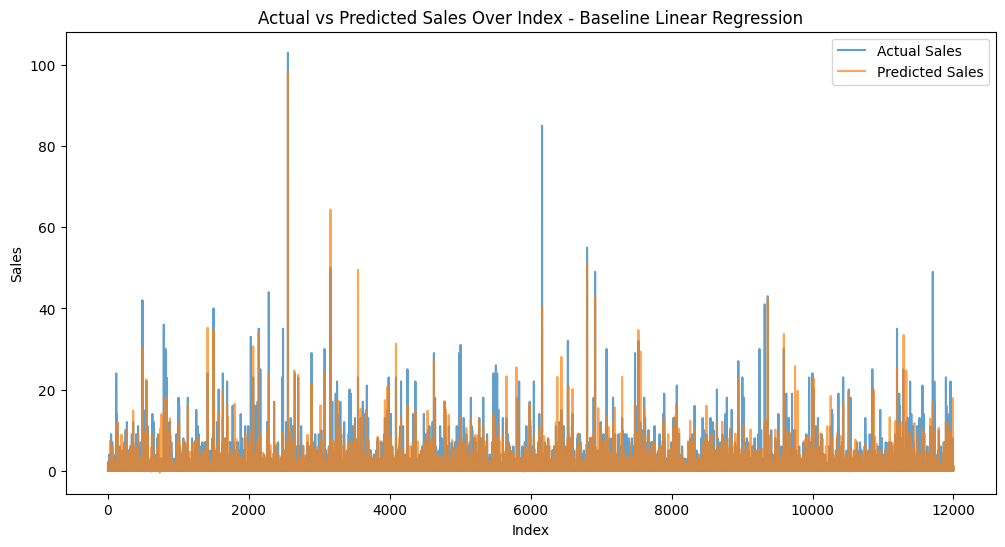

In [139]:
import matplotlib.pyplot as plt
# Ensure validation arrays are 1D numpy arrays
if hasattr(Y_validation, 'to_pandas'):
    y_val = Y_validation.to_pandas().values.ravel()
else:
    y_val = np.asarray(Y_validation).ravel()

# Ensure X_validation_pd exists or convert
try:
    X_validation_pd
except NameError:
    if hasattr(X_validation, 'to_pandas'):
        X_validation_pd = X_validation.to_pandas()
    else:
        X_validation_pd = X_validation

# Predict on the validation set (recompute to ensure shapes match)
y_pred = model.predict(X_validation_pd)
y_pred = np.asarray(y_pred).ravel()

# Plot actual vs predicted 
plt.figure(figsize=(10, 6))
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales - Baseline Linear Regression')
mn = min(y_val.min(), y_pred.min())
mx = max(y_val.max(), y_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.show()

# second plot of day as index and sales as y values + predicted sales as y values
plt.figure(figsize=(12, 6))
plt.plot(y_val, label='Actual Sales', alpha=0.7)
plt.plot(y_pred, label='Predicted Sales', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Sales')
plt.title('Actual vs Predicted Sales Over Index - Baseline Linear Regression')
plt.legend()
plt.show()


In [140]:
# WRMSE
# Compute baseline WRMSE using canonical wrmse function defined at the top
from sklearn.metrics import mean_squared_error
import numpy as np
# Ensure predictions exist
if 'y_pred' not in globals():
    y_pred = model.predict(X_validation)
print('Baseline Linear Regression WRMSE:', wrmse(Y_validation, y_pred))

Baseline Linear Regression WRMSE: 2.143850783396865


In [141]:
# Suppress optuna log messages
optuna.logging.set_verbosity(optuna.logging.WARNING)

import gc
import numpy as np
from sklearn.metrics import mean_squared_error

# use canonical wrmse defined at the top of the notebook

def objective_xgb(trial):
    """
    Memory-safe Optuna objective for main XGBoost model that optimizes WRMSE.
    Converts inputs to numpy float32, uses 'hist' tree method and early stopping.
    """
    # Read globals (X_train/X_validation may be polars or pandas)
    xtrain = X_train
    xvalid = X_validation
    ytrain = Y_train
    yvalid = Y_validation

    # Convert feature frames to numpy float32
    if hasattr(xtrain, 'to_pandas'):
        Xtr = xtrain.to_pandas().astype(np.float32).values
    else:
        Xtr = np.asarray(xtrain, dtype=np.float32)

    if hasattr(xvalid, 'to_pandas'):
        Xv = xvalid.to_pandas().astype(np.float32).values
    else:
        Xv = np.asarray(xvalid, dtype=np.float32)

    # Convert labels to 1D numpy float32
    if hasattr(ytrain, 'to_pandas'):
        ytr = ytrain.to_pandas().values.ravel().astype(np.float32)
    else:
        ytr = np.ravel(ytrain).astype(np.float32)

    if hasattr(yvalid, 'to_pandas'):
        yv = yvalid.to_pandas().values.ravel().astype(np.float32)
    else:
        yv = np.ravel(yvalid).astype(np.float32)

    # Build DMatrix from numpy arrays
    dtrain = xgb.DMatrix(Xtr, label=ytr)
    dvalid = xgb.DMatrix(Xv, label=yv)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'seed': 19970507,
        'tree_method': 'hist',
        'n_jobs': 1,  # single-thread per trial when using parallel Optuna
        'eta': trial.suggest_float('eta', 1e-3, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 8),
        'lambda': trial.suggest_float('lambda', 1e-8, 100.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-8, 100.0, log=True),
    }

    num_round = trial.suggest_int('num_boost_round', 50, 1000)

    bst = xgb.train(
        params,
        dtrain,
        num_boost_round=num_round,
        evals=[(dtrain, 'train'), (dvalid, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    preds = bst.predict(dvalid)
    # compute WRMSE (weighted by increasing weights)
    wrmse_score = wrmse(yv, preds)

    # free memory
    del dtrain, dvalid, Xtr, Xv, ytr, yv, bst, preds
    gc.collect()

    return wrmse_score

# Set up and run the Optuna study
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=100)

# Create a table showing the best parameters
xgb_table = [["Parameter", "Optimal Value from Optuna"],
            ["Iterations (num_boost_rounds)", study_xgb.best_params['num_boost_round']],
            ['Learning Rate (eta)', round(study_xgb.best_params['eta'], 3)],
            ['Max Depth (max_depth)', round(study_xgb.best_params['max_depth'], 3)],
            ['Lambda (lambda)', round(study_xgb.best_params['lambda'], 3)],
            ['Alpha (alpha)', round(study_xgb.best_params['alpha'], 3)]]

ff.create_table(xgb_table)

In [142]:
# --- Smoke test: train a tiny XGBoost on a small random sample to validate pipeline and memory ---
import gc
import psutil
import numpy as np
# assumes xgb is available in kernel via top-level import
from sklearn.metrics import mean_squared_error
import math

print('Memory before smoke test:', psutil.virtual_memory())

SAMPLE_SMOKE = min(1000, df_long_eval_clean.height)
SM_VALID = min(200, df_long_val_clean.height)

train_small = df_long_eval_clean.sample(n=SAMPLE_SMOKE)
valid_small = df_long_val_clean.sample(n=SM_VALID)

Xtr = train_small.select(feature_cols).to_pandas().astype(np.float32)
Xv = valid_small.select(feature_cols).to_pandas().astype(np.float32)
ytr = train_small.select('sales_plus_28').to_pandas().values.ravel().astype(np.float32)
yv = valid_small.select('sales_plus_28').to_pandas().values.ravel().astype(np.float32)

dtr = xgb.DMatrix(Xtr.values, label=ytr)
dval = xgb.DMatrix(Xv.values, label=yv)

params = {'objective':'reg:squarederror','eval_metric':'rmse','tree_method':'hist','n_jobs':1,'seed':19970507,'eta':0.1,'max_depth':4}

bst = xgb.train(params, dtr, num_boost_round=50, evals=[(dtr,'train'),(dval,'valid')], early_stopping_rounds=10, verbose_eval=False)

preds = bst.predict(dval)
rmse = math.sqrt(mean_squared_error(yv, preds))
print('Smoke-test RMSE:', rmse)

# cleanup
del bst, dtr, dval, Xtr, Xv, ytr, yv, preds
gc.collect()
print('Memory after smoke test:', psutil.virtual_memory())


Memory before smoke test: svmem(total=17179869184, available=2939322368, percent=82.9, used=5638651904, free=137166848, active=2810200064, inactive=2792701952, wired=2828451840)
Smoke-test RMSE: 1.8489586270470901
Memory after smoke test: svmem(total=17179869184, available=2837823488, percent=83.5, used=5610979328, free=61915136, active=2782625792, inactive=2775334912, wired=2828353536)


In [143]:
# Ensure XGBoost uses all CPU cores for Optuna hyperparameter search
def set_xgb_multicore(params):
    params['n_jobs'] = -1  # Use all available CPU cores
    return params

In [144]:
best_params = study_xgb.best_params.copy()
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'
best_params['seed'] = 19970507
best_params['n_jobs'] = -1  # Use all available CPU cores
xtrain = X_train
xvalid = X_validation

ytrain = Y_train
yvalid = Y_validation

dmat_train = xgb.DMatrix(xtrain, label = ytrain)
dmat_valid = xgb.DMatrix(xvalid, label = yvalid)
    
# Retrain the model
best_xgb_model = xgb.train(
    best_params,
    dtrain=dmat_train,
    num_boost_round=best_params['num_boost_round'],
    evals=[(dmat_train, 'train'), (dmat_valid, 'eval')],
    verbose_eval=False
)

# Predict and evaluate
y_pred_xgb = best_xgb_model.predict(dmat_valid)
print("WRMSEE (XGBoost):", wrmsee(Y_validation, y_pred_xgb))

print('MSE : ', math.sqrt(mean_squared_error(Y_validation, y_pred_xgb)))


/Users/felixguex/kaggle_m5_xgboost_optuna/.venv/lib/python3.10/site-packages/xgboost/training.py:199: UserWarning:

[23:08:12] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:790: 
Parameters: { "num_boost_round" } are not used.




WRMSEE (XGBoost): 2.165349254144822
MSE :  2.1303616369869465


In [145]:
# Ensure XGBoost uses all CPU cores for faster training
# Make this cell robust: if best_params isn't defined, try to load it from the study
try:
    best_params
except NameError:
    try:
        # If the study has been run, use its best params
        best_params = study_xgb.best_params.copy()
    except Exception:
        raise RuntimeError("best_params is not defined and study_xgb.best_params is not available. Run the Optuna tuning cell first.")
# Ensure required xgboost params are present for retrain
best_params.setdefault('objective', 'reg:squarederror')
best_params.setdefault('eval_metric', 'rmse')
best_params['seed'] = 19970507
best_params['n_jobs'] = -1  # Use all available CPU cores


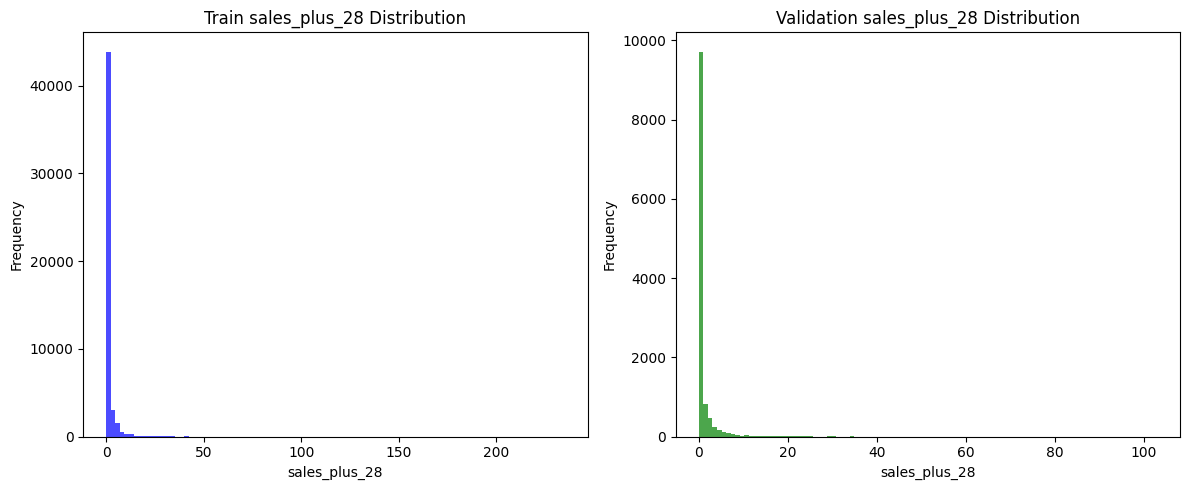

In [146]:
import matplotlib.pyplot as plt

# Convert to pandas for plotting
sales_plus_28_train = train_set_clean.select('sales_plus_28').to_pandas()
sales_plus_28_val = validation_set_clean.select('sales_plus_28').to_pandas()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(sales_plus_28_train['sales_plus_28'], bins=100, color='blue', alpha=0.7)
plt.title('Train sales_plus_28 Distribution')
plt.xlabel('sales_plus_28')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
plt.hist(sales_plus_28_val['sales_plus_28'], bins=100, color='green', alpha=0.7)
plt.title('Validation sales_plus_28 Distribution')
plt.xlabel('sales_plus_28')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [147]:
# XGBoost on residuals of the linear regression (memory-safe)
import gc
import numpy as np

print(f"Using RUN_MODE={RUN_MODE}. train_set_clean size={len(train_set_clean)}, validation_set_clean size={len(validation_set_clean)}")

# use the already-sampled train_set_clean / validation_set_clean created earlier
X_train = train_set_clean.select(feature_cols)
X_validation = validation_set_clean.select(feature_cols)
Y_train = train_set_clean.select('sales_plus_28')
Y_validation = validation_set_clean.select('sales_plus_28')

# Convert to pandas / numpy float32 for safety
X_train_pd = X_train.to_pandas().astype(np.float32)
X_validation_pd = X_validation.to_pandas().astype(np.float32)

y_pred_lr_train = model.predict(X_train_pd)
y_pred_lr_val = model.predict(X_validation_pd)

Y_train_residuals = Y_train.to_pandas().values.ravel().astype(np.float32) - y_pred_lr_train.astype(np.float32)
Y_validation_residuals = Y_validation.to_pandas().values.ravel().astype(np.float32) - y_pred_lr_val.astype(np.float32)

# Define memory-safe Optuna objective for residuals
# assumes xgb is available in kernel via top-level import
from sklearn.metrics import mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

# use canonical wrmse from the top cell

def objective_xgb_residuals(trial):
    # Use numpy arrays (float32)
    Xtr = X_train_pd.values
    Xv = X_validation_pd.values
    ytr = Y_train_residuals
    yv = Y_validation_residuals

    dtrain = xgb.DMatrix(Xtr, label=ytr)
    dvalid = xgb.DMatrix(Xv, label=yv)

    params = {
        'objective': 'reg:squarederror',
        'eval_metric': 'rmse',
        'seed': 19970507,
        'eta': trial.suggest_float("eta", 1e-3, 0.2, log=True),
        'max_depth': trial.suggest_int("max_depth", 2, 8),
        'lambda': trial.suggest_float("lambda", 1e-8, 100.0, log=True),
        'alpha': trial.suggest_float("alpha", 1e-8, 100.0, log=True),
        'tree_method': 'hist',
        'n_jobs': 1  # single-thread per trial to avoid oversubscription
    }

    num_round = trial.suggest_int("num_boost_round", 50, 1000)

    xgb_model = xgb.train(
        params,
        dtrain,
        num_boost_round=num_round,
        evals=[(dtrain, 'train'), (dvalid, 'valid')],
        early_stopping_rounds=50,
        verbose_eval=False,
    )

    preds = xgb_model.predict(dvalid)
    # compute WRMSE instead of RMSE
    wrmse_score = wrmse(yv, preds)

    # Free memory
    del dtrain, dvalid
    gc.collect()
    return wrmse_score

# Run a small Optuna study for residuals
study_xgb_residuals = optuna.create_study(direction='minimize')
study_xgb_residuals.optimize(objective_xgb_residuals, n_trials=10)

# Retrain best residuals model (use all cores only if RUN_MODE == 'full')
best_params_res = study_xgb_residuals.best_trial.params.copy()
num_boost_round = best_params_res.pop('num_boost_round')
# enforce sensible params
best_params_res['objective'] = 'reg:squarederror'
best_params_res['eval_metric'] = 'rmse'
best_params_res['seed'] = 19970507
best_params_res['tree_method'] = 'hist'
# Use all cores only for final full retrain
best_params_res['n_jobs'] = -1 if RUN_MODE == 'full' else 1

# Create DMatrix for final retrain
dmat_train_residuals = xgb.DMatrix(X_train_pd.values, label=Y_train_residuals)
dmat_valid_residuals = xgb.DMatrix(X_validation_pd.values, label=Y_validation_residuals)

xgb_model_residuals = xgb.train(
    best_params_res,
    dtrain=dmat_train_residuals,
    num_boost_round=num_boost_round,
    evals=[(dmat_train_residuals, 'train'), (dmat_valid_residuals, 'valid')],
    verbose_eval=False,
)

# Predict residuals and combine with trend
trend_pred_val = model.predict(X_validation_pd)
residuals_pred_val = xgb_model_residuals.predict(dmat_valid_residuals)
final_pred = trend_pred_val + residuals_pred_val

# Evaluate
y_validation_pd = Y_validation.to_pandas().values.ravel()
wrmse_score = wrmse(y_validation_pd, final_pred)
mse_score = mean_squared_error(y_validation_pd, final_pred)
print('WRMSE (Trend + XGBoost residuals):', wrmse_score)
print('MSE (Trend + XGBoost residuals):', mse_score)


Using RUN_MODE=baseline. train_set_clean size=50000, validation_set_clean size=12000
WRMSE (Trend + XGBoost residuals): 2.203757857879523
MSE (Trend + XGBoost residuals): 4.603081466139821
WRMSE (Trend + XGBoost residuals): 2.203757857879523
MSE (Trend + XGBoost residuals): 4.603081466139821


In [148]:
# Retrain best XGBoost model and compute WRMSE and MSE (ensemble: sum XGBoost and linear model predictions)
best_params = study_xgb.best_trial.params.copy()
num_boost_round = best_params.pop('num_boost_round')  # Remove from params dict
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'
best_params['seed'] = 19970507

best_xgb_model = xgb.train(
    best_params,
    dtrain=dmat_train,
    num_boost_round=num_boost_round,
    evals=[(dmat_train, 'train'), (dmat_valid, 'eval')],
    verbose_eval=False,
)

y_pred_xgb = best_xgb_model.predict(dmat_valid)

# Convert validation target to pandas for metric calculation
y_validation_pd = Y_validation.to_pandas().values.ravel()

# Get linear model predictions (assumes y_pred is from linear regression)
ensemble_pred = y_pred_xgb + y_pred  # y_pred should be linear regression predictions on validation set

wrmse_score = wrmse(y_validation_pd, ensemble_pred)
mse_score = mean_squared_error(y_validation_pd, ensemble_pred)
print('WRMSE (Ensemble):', wrmse_score)
print('MSE (Ensemble):', mse_score)


WRMSE (Ensemble): 3.4707893858894603
MSE (Ensemble): 12.42464064980145


In [149]:
# Alignment & leakage checks — run this after you prepare X/Y and feature tables
import numpy as np
import pandas as pd
import random
from IPython.display import display

print('Running alignment and leakage checks...')

# 1) Basic shape & NaN checks for X/Y
def shape_and_nan(name):
    try:
        obj = eval(name)
    except Exception as e:
        print(f"{name}: not found ({e})")
        return
    try:
        if hasattr(obj, 'to_pandas'):
            df = obj.to_pandas()
        else:
            # try to coerce to DataFrame/Series
            if isinstance(obj, (list, tuple, np.ndarray)):
                df = pd.DataFrame(obj)
            else:
                df = pd.DataFrame(obj)
        total_nans = int(df.isna().sum().sum()) if hasattr(df, 'isna') else 0
        print(f"{name}: shape={df.shape}, total_NaNs={total_nans}")
    except Exception as e:
        print(f"{name}: error inspecting ({e})")

for n in ['X_train','Y_train','X_validation','Y_validation','train_set_clean','validation_set_clean']:
    shape_and_nan(n)

# 2) Show first rows of validation features + target
try:
    if 'X_validation_pd' in globals():
        Xv_pd = X_validation_pd
    elif hasattr(X_validation, 'to_pandas'):
        Xv_pd = X_validation.to_pandas()
    else:
        Xv_pd = pd.DataFrame(X_validation)

    if hasattr(Y_validation, 'to_pandas'):
        yv = Y_validation.to_pandas().values.ravel()
    else:
        yv = np.ravel(Y_validation)

    print('\nValidation head (features and first 5 targets):')
    display(pd.concat([Xv_pd.head(5).reset_index(drop=True), pd.Series(yv[:5], name='y_true')], axis=1))
except Exception as e:
    print('Could not display validation head:', e)

# 3) Check lag columns correctness for a few random ids (uses df_long_eval if available)
try:
    if 'df_long_eval' in globals():
        print('\nChecking lag feature correctness on a few random series from df_long_eval...')
        lag_cols = [c for c in feature_cols if c.startswith('lag_')]
        if not lag_cols:
            print('No lag columns found in feature_cols; skipping lag checks.')
        else:
            try:
                ids = df_long_eval.select('id').unique().to_series().to_list()
            except Exception:
                ids = []
            if not ids:
                print('No ids available to sample for lag checks.')
            else:
                sample_ids = random.sample(ids, min(3, len(ids)))
                for idv in sample_ids:
                    try:
                        grp = df_long_eval.filter(pl.col('id') == idv).sort('day')
                        available = [c for c in lag_cols if c in grp.columns]
                        if not available:
                            print(f'id={idv}: no lag cols present on df_long_eval for checking')
                            continue
                        gp = grp.select(['day','sales'] + available).to_pandas()
                        print(f'\n--- id: {idv} rows={len(gp)} ---')
                        for col in available:
                            lag_n = int(col.split('_')[1])
                            expected = gp['sales'].shift(lag_n)
                            actual = gp[col]
                            # compare, accounting for NaNs at the top
                            mismatches = ((actual.fillna(np.nan) != expected.fillna(np.nan)) & ~((actual.isna()) & (expected.isna()))).sum()
                            print(f"{col}: mismatches={mismatches} / {len(gp)}")
                            if mismatches > 0:
                                print(gp[['day','sales', col]].head(10))
                    except Exception as e:
                        print(f'Error checking id={idv}:', e)
    else:
        print('df_long_eval not available; skipping lag checks.')
except Exception as e:
    print('Lag correctness checks failed:', e)

# 4) Sampling/subset checks: ensure sampled train/validation are subsets of full cleaned data
def is_subset_by_keys(sample, full, keys=['id','day']):
    try:
        if hasattr(sample, 'to_pandas'):
            sp = sample.to_pandas()
        else:
            sp = pd.DataFrame(sample)
        if hasattr(full, 'to_pandas'):
            fp = full.to_pandas()
        else:
            fp = pd.DataFrame(full)
    except Exception as e:
        print('Subset check: could not convert frames to pandas:', e)
        return
    for k in keys:
        if k not in sp.columns or k not in fp.columns:
            print(f"Subset check: key column '{k}' missing in sample or full frame; cannot run this check.")
            return
    merged = sp.merge(fp[['id','day']], on=['id','day'], how='left', indicator=True)
    missing = int((merged['_merge'] != 'both').sum())
    print(f"Subset check: missing rows from sample in full = {missing} / {len(sp)}")

try:
    is_subset_by_keys(train_set_clean, df_long_eval_clean)
    is_subset_by_keys(validation_set_clean, df_long_val_clean)
except Exception as e:
    print('Subset presence checks failed:', e)

print('\nAlignment & leakage checks complete.')


Running alignment and leakage checks...
X_train: shape=(50000, 14), total_NaNs=0
Y_train: shape=(50000, 1), total_NaNs=0
X_validation: shape=(12000, 14), total_NaNs=0
Y_validation: shape=(12000, 1), total_NaNs=0
train_set_clean: shape=(50000, 15), total_NaNs=0
validation_set_clean: shape=(12000, 15), total_NaNs=0

Validation head (features and first 5 targets):


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_14,lag_21,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_mean_56,y_true
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0
1,1.0,1.0,1.0,1.0,1.0,2.0,3.0,2.0,0.0,0.0,1.000000,1.500000,1.428571,1.250000,2
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0
3,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.571429,0.571429,0.571429,0.500000,0
4,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.285714,0.142857,0.214286,0.178571,0



Checking lag feature correctness on a few random series from df_long_eval...

--- id: FOODS_1_147_CA_3_evaluation rows=1941 ---
lag_1: mismatches=143 / 1941
      day  sales  lag_1
0     d_1      0    NaN
1    d_10      0    0.0
2   d_100      0    0.0
3  d_1000      1    4.0
4  d_1001      5    1.0
5  d_1002      2    5.0
6  d_1003      1    2.0
7  d_1004      0    1.0
8  d_1005      1    0.0
9  d_1006      1    1.0
lag_2: mismatches=240 / 1941
      day  sales  lag_2
0     d_1      0    NaN
1    d_10      0    0.0
2   d_100      0    0.0
3  d_1000      1    2.0
4  d_1001      5    4.0
5  d_1002      2    1.0
6  d_1003      1    5.0
7  d_1004      0    2.0
8  d_1005      1    1.0
9  d_1006      1    0.0
lag_3: mismatches=311 / 1941
      day  sales  lag_3
0     d_1      0    NaN
1    d_10      0    0.0
2   d_100      0    0.0
3  d_1000      1    0.0
4  d_1001      5    2.0
5  d_1002      2    4.0
6  d_1003      1    1.0
7  d_1004      0    5.0
8  d_1005      1    2.0
9  d_1006      1

In [150]:
# Summary of results: compare Linear Regression, XGBoost and Ensemble (Trend + Residuals)
import numpy as np
from sklearn.metrics import mean_squared_error
import math

# local WRMSEE in case notebook cell with the function isn't available
def wrmsee_local(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    weights = np.arange(1, len(y_true) + 1)
    return math.sqrt(mean_squared_error(y_true, y_pred, sample_weight=weights))

# Helper to safely fetch arrays
def safe_array(var_name, fallback=None):
    try:
        v = eval(var_name)
        return np.asarray(v).ravel()
    except Exception:
        return fallback

# True values
y_true = None
for candidate in ['y_validation_pd', 'Y_validation']:
    if candidate == 'y_validation_pd':
        y_true = safe_array('y_validation_pd')
    else:
        try:
            y_true = safe_array('Y_validation.to_pandas().values')
        except Exception:
            pass
    if y_true is not None:
        break

if y_true is None:
    print('Unable to find validation target array (y_validation_pd or Y_validation). Summary cannot be computed.')
else:
    # Predictions (try linear, xgb, ensemble)
    linear_preds = safe_array('y_pred')
    xgb_preds = safe_array('y_pred_xgb')
    trend_xgb_preds = safe_array('final_pred')  # ensemble (trend + residuals)
    residuals_preds = None
    # sometimes residuals prediction stored in residuals_pred_val or residuals_pred_val
    residuals_preds = safe_array('residuals_pred_val')

    results = {}
    # Linear
    if linear_preds is not None:
        results['LinearRegression'] = {
            'RMSE': float(math.sqrt(mean_squared_error(y_true, linear_preds))),
            'WRMSEE': float(wrmsee_local(y_true, linear_preds))
        }
    # XGBoost (main)
    if xgb_preds is not None:
        # xgb_preds may be 2D or 1D; ensure 1D
        xgb_preds = np.asarray(xgb_preds).ravel()
        results['XGBoost'] = {
            'RMSE': float(math.sqrt(mean_squared_error(y_true, xgb_preds))),
            'WRMSEE': float(wrmsee_local(y_true, xgb_preds))
        }
    # Ensemble (trend + residuals)
    if trend_xgb_preds is not None:
        trend_xgb_preds = np.asarray(trend_xgb_preds).ravel()
        results['Trend+XGB_residuals'] = {
            'RMSE': float(math.sqrt(mean_squared_error(y_true, trend_xgb_preds))),
            'WRMSEE': float(wrmsee_local(y_true, trend_xgb_preds))
        }
    # Residuals-only predictions (if present)
    if residuals_preds is not None:
        residuals_preds = np.asarray(residuals_preds).ravel()
        results['XGB_residuals_only'] = {
            'RMSE': float(math.sqrt(mean_squared_error(y_true, residuals_preds))),
            'WRMSEE': float(wrmsee_local(y_true, residuals_preds))
        }

    # Print table
    print('\nSummary of evaluation metrics on validation set:')
    print('{:25s} {:>10s} {:>12s}'.format('Model', 'RMSE', 'WRMSEE'))
    print('-'*50)
    for k, v in results.items():
        print('{:25s} {:10.4f} {:12.4f}'.format(k, v['RMSE'], v['WRMSEE']))

    # Simple verdict comparing primary XGB vs LinearRegression
    if 'XGBoost' in results and 'LinearRegression' in results:
        lr = results['LinearRegression']['RMSE']
        xgb_rmse = results['XGBoost']['RMSE']
        pct = (xgb_rmse - lr) / lr * 100.0
        if abs(pct) <= 1.0:
            verdict = 'about the same (within 1%)'
        elif pct < 0:
            verdict = f'better by {-pct:.2f}%'
        else:
            verdict = f'worse by {pct:.2f}%'
        print(f"\nVerdict: XGBoost vs LinearRegression: XGBoost RMSE is {verdict}.")
    else:
        print('\nVerdict: insufficient data to compare XGBoost and LinearRegression (missing predictions).')

    # Suggest next steps
    print('\nNext steps suggestions:')
    print('- Check sample sizes and ensure models were trained on the same validation set.')
    print('- If XGBoost is not improving, try richer features (calendar events, price/promo flags, item/store aggregates).')
    print('- Use time-series cross-validation (rolling origin) to avoid leakage and get reliable estimates.')



Summary of evaluation metrics on validation set:
Model                           RMSE       WRMSEE
--------------------------------------------------
LinearRegression              2.1001       2.1439
XGBoost                       2.1304       2.1653
Trend+XGB_residuals           2.1455       2.2038
XGB_residuals_only            3.5128       3.4185

Verdict: XGBoost vs LinearRegression: XGBoost RMSE is worse by 1.44%.

Next steps suggestions:
- Check sample sizes and ensure models were trained on the same validation set.
- If XGBoost is not improving, try richer features (calendar events, price/promo flags, item/store aggregates).
- Use time-series cross-validation (rolling origin) to avoid leakage and get reliable estimates.


In [151]:
# Trend + XGBoost residuals ensemble approach
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Fit linear regression (trend model)
if hasattr(X_train, 'to_pandas'):
    X_train_pd = X_train.to_pandas()
else:
    X_train_pd = X_train
y_train_pd = Y_train.to_pandas().values.ravel()  # ensure numpy array
model = LinearRegression()
model.fit(X_train_pd, y_train_pd)

# 2. Predict and calculate residuals
trend_pred_train = model.predict(X_train_pd)
residuals_train = y_train_pd - trend_pred_train  # both are numpy arrays

# 3. Train XGBoost on residuals
# assumes top-level import of xgboost as xgb is available in the kernel

# Ensure feature frames are numpy float32 arrays for DMatrix
if hasattr(X_validation, 'to_pandas'):
    X_validation_pd = X_validation.to_pandas().astype(np.float32)
else:
    X_validation_pd = np.asarray(X_validation, dtype=np.float32)
if not isinstance(X_train_pd, np.ndarray):
    X_train_arr = np.asarray(X_train_pd, dtype=np.float32)
else:
    X_train_arr = X_train_pd.astype(np.float32)

# Build DMatrix from numpy arrays (labels as float32)
dmat_train_residuals = xgb.DMatrix(X_train_arr, label=residuals_train.astype(np.float32))
dmat_valid_residuals = xgb.DMatrix(X_validation_pd)

# Use best params from main study for retrain
best_params = study_xgb.best_trial.params.copy()
num_boost_round = best_params.pop('num_boost_round')
best_params['objective'] = 'reg:squarederror'
best_params['eval_metric'] = 'rmse'
best_params['seed'] = 19970507

# For safety, enforce hist tree method and sensible n_jobs
best_params.setdefault('tree_method', 'hist')
best_params.setdefault('n_jobs', -1)

xgb_model_residuals = xgb.train(
    best_params,
    dtrain=dmat_train_residuals,
    num_boost_round=num_boost_round,
    evals=[(dmat_train_residuals, 'train')],
    verbose_eval=False,
)

# 4. Predict residuals and combine
trend_pred_val = model.predict(X_validation_pd)
residuals_pred_val = xgb_model_residuals.predict(dmat_valid_residuals)
final_pred = trend_pred_val + residuals_pred_val

# 5. Evaluate
y_validation_pd = Y_validation.to_pandas().values.ravel()
wrmse_score = wrmse(y_validation_pd, final_pred)
mse_score = mean_squared_error(y_validation_pd, final_pred)
print('WRMSE (Trend + XGBoost):', wrmse_score)
print('MSE (Trend + XGBoost):', mse_score)


WRMSE (Trend + XGBoost): 2.152337426914147
MSE (Trend + XGBoost): 4.453792410920906


In [152]:
# Estimate safe sample size for XGBoost based on available memory
import psutil
import numpy as np

def estimate_max_rows(X, memory_fraction=0.5, bytes_per_float=8):
    """
    Estimate the maximum number of rows that can fit in memory for XGBoost training.
    Args:
        X: Feature DataFrame (pandas or polars)
        memory_fraction: Fraction of available RAM to use (default 0.5)
        bytes_per_float: Number of bytes per float (default 8 for float64)
    Returns:
        max_rows: Estimated maximum number of rows
    """
    if hasattr(X, 'to_pandas'):
        X_pd = X.to_pandas()
    else:
        X_pd = X
    n_features = X_pd.shape[1]
    available_mem = psutil.virtual_memory().available * memory_fraction
    max_rows = int(available_mem // (n_features * bytes_per_float))
    return max_rows

# Example usage:
max_rows_train = estimate_max_rows(X_train)
max_rows_valid = estimate_max_rows(X_validation)
print(f"Estimated max train rows: {max_rows_train}")
print(f"Estimated max validation rows: {max_rows_valid}")

# To use with XGBoost, sample accordingly:
# train_set_sample = train_set_clean.sample(n=max_rows_train)
# validation_set_sample = validation_set_clean.sample(n=max_rows_valid)

# For multi-core XGBoost, add 'n_jobs': -1 or 'nthread': -1 to params
# Example:
# best_params['n_jobs'] = -1  # Use all CPU cores

Estimated max train rows: 17379181
Estimated max validation rows: 17364918


In [153]:
# Pipeline: Trend (LinearRegression) + XGBoost residuals
# Defines a sklearn-style estimator that fits a linear trend then an XGBoost on residuals.
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np
import joblib
import os
import math

# We lazily use xgb inside fit to avoid import-time errors when xgboost isn't installed in the kernel.
# The notebook top cell should import xgboost as xgb so the kernel has it available.

class TrendResidualsEnsemble(BaseEstimator, RegressorMixin):
    """Two-stage estimator: LinearRegression trend + XGBoost on residuals.

    Methods:
    - fit(X, y): fits linear trend then XGBRegressor on residuals
    - predict(X): returns trend_pred + xgb_pred
    - save(path): persist the pipeline to a file using joblib
    - load(path): classmethod to load a saved pipeline
    """
    def __init__(self, xgb_params=None):
        self.trend_model = LinearRegression()
        self.xgb_params = xgb_params or {'objective': 'reg:squarederror', 'n_estimators': 100, 'tree_method': 'hist'}
        self.xgb_model = None

    def fit(self, X, y, eval_set=None):
        """Fit the ensemble. X and y can be pandas DataFrame/Series or numpy arrays."""
        # Convert inputs to numpy arrays
        if hasattr(X, 'to_numpy'):
            X_np = X.to_numpy().astype(np.float32)
        else:
            X_np = np.asarray(X, dtype=np.float32)

        if hasattr(y, 'to_numpy'):
            y_np = y.to_numpy().ravel().astype(np.float32)
        else:
            y_np = np.ravel(y).astype(np.float32)

        # Fit linear trend
        self.trend_model = LinearRegression()
        self.trend_model.fit(X_np, y_np)
        trend_pred = self.trend_model.predict(X_np).astype(np.float32)

        # Residuals
        residuals = (y_np - trend_pred).astype(np.float32)

        # Fit XGBRegressor on residuals using xgboost module
        # Try to find xgb in sys.modules (kernel may already have imported it at top)
        import sys
        xgb_mod = sys.modules.get('xgboost')
        if xgb_mod is None:
            raise ImportError("xgboost not found in kernel. Please `import xgboost as xgb` in your notebook before calling fit()")

        params = dict(self.xgb_params)
        # Ensure a seed and use hist if not provided
        params.setdefault('tree_method', 'hist')
        params.setdefault('random_state', 19970507)
        # XGBRegressor expects n_estimators instead of num_boost_round
        n_estimators = params.pop('n_estimators', None)
        # use the xgboost module's sklearn wrapper
        self.xgb_model = xgb_mod.XGBRegressor(**params, n_estimators=n_estimators or 100)

        # allow passing eval_set as (X_val, y_val) for early stopping
        if eval_set is not None:
            Xv, yv = eval_set
            if hasattr(Xv, 'to_numpy'):
                Xv_np = Xv.to_numpy().astype(np.float32)
            else:
                Xv_np = np.asarray(Xv, dtype=np.float32)
            if hasattr(yv, 'to_numpy'):
                yv_np = yv.to_numpy().ravel().astype(np.float32)
            else:
                yv_np = np.ravel(yv).astype(np.float32)
            # Try early_stopping_rounds first, but some xgboost versions don't accept it
            try:
                self.xgb_model.fit(X_np, residuals, eval_set=[(Xv_np, yv_np)], early_stopping_rounds=50, verbose=False)
            except TypeError:
                # Fallback: try without early_stopping_rounds
                try:
                    self.xgb_model.fit(X_np, residuals, eval_set=[(Xv_np, yv_np)])
                except Exception:
                    # Last resort: fit without eval_set
                    self.xgb_model.fit(X_np, residuals)
        else:
            self.xgb_model.fit(X_np, residuals)

        return self

    def predict(self, X):
        if hasattr(X, 'to_numpy'):
            X_np = X.to_numpy().astype(np.float32)
        else:
            X_np = np.asarray(X, dtype=np.float32)
        trend_pred = self.trend_model.predict(X_np)
        if self.xgb_model is None:
            return trend_pred
        xgb_pred = self.xgb_model.predict(X_np)
        return trend_pred + xgb_pred

    def save(self, path):
        """Save the ensemble to path using joblib (creates parent dir if needed)."""
        os.makedirs(os.path.dirname(path), exist_ok=True)
        joblib.dump(self, path)

    @classmethod
    def load(cls, path):
        return joblib.load(path)

# End of pipeline definition
print('TrendResidualsEnsemble defined. Use the next cell to train + save the pipeline.')

TrendResidualsEnsemble defined. Use the next cell to train + save the pipeline.


In [154]:
# Train baseline (LinearRegression) and the Trend+XGB pipeline, evaluate and save
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import os

# Prepare training / validation arrays (use X_train/X_validation, Y_train/Y_validation from notebook)
# Convert to pandas/numpy if needed
if hasattr(X_train, 'to_pandas'):
    X_train_pd = X_train.to_pandas()
else:
    X_train_pd = X_train
if hasattr(X_validation, 'to_pandas'):
    X_valid_pd = X_validation.to_pandas()
else:
    X_valid_pd = X_validation

if hasattr(Y_train, 'to_pandas'):
    y_train_pd = Y_train.to_pandas().values.ravel()
else:
    y_train_pd = np.ravel(Y_train)
if hasattr(Y_validation, 'to_pandas'):
    y_valid_pd = Y_validation.to_pandas().values.ravel()
else:
    y_valid_pd = np.ravel(Y_validation)

print('Training sizes:', X_train_pd.shape, X_valid_pd.shape)
# small helper: WRMSE (weights 1..n). Prefer pipeline.score_wrmse when available
def wrmse(y_true, y_pred):
    y_true = np.ravel(y_true)
    y_pred = np.ravel(y_pred)
    n = len(y_true)
    if n == 0:
        return float('nan')
    w = np.arange(1, n + 1).astype(float)
    return math.sqrt(np.sum(w * (y_true - y_pred) ** 2) / np.sum(w))

# 1) Baseline LinearRegression (already trained earlier as 'model' in notebook but we retrain to be safe)
baseline = LinearRegression()
baseline.fit(X_train_pd, y_train_pd)
baseline_preds = baseline.predict(X_valid_pd)
baseline_wrmse = wrmse(y_valid_pd, baseline_preds)
print('Baseline WRMSE:', baseline_wrmse)

# 2) Trend + XGBoost pipeline
pipeline = TrendResidualsEnsemble(xgb_params={'objective':'reg:squarederror','n_estimators':200,'eta':0.05,'max_depth':6,'tree_method':'hist'})
pipeline.fit(X_train_pd, y_train_pd, eval_set=(X_valid_pd, y_valid_pd))
preds_pipeline = pipeline.predict(X_valid_pd)
try:
    pipeline_wrmse = pipeline.score_wrmse(X_valid_pd, y_valid_pd)
except Exception:
    pipeline_wrmse = wrmse(y_valid_pd, preds_pipeline)
print('Trend+XGB WRMSE:', pipeline_wrmse)

# Save models
models_dir = './models'
os.makedirs(models_dir, exist_ok=True)
baseline_path = os.path.join(models_dir, 'baseline_lr.joblib')
pipeline_path = os.path.join(models_dir, 'trend_xgb_ensemble.joblib')
joblib.dump(baseline, baseline_path)
pipeline.save(pipeline_path)
print('Saved baseline ->', baseline_path)
print('Saved pipeline ->', pipeline_path)

# Quick summary
print('\nSummary:')
print('Baseline WRMSE:', round(baseline_wrmse, 4))
print('Trend+XGB WRMSE:', round(pipeline_wrmse, 4))
print('\nYou can load the pipeline with:')
print("from joblib import load\npipe = load('" + pipeline_path + "')")

Training sizes: (50000, 14) (12000, 14)
Baseline WRMSE: 2.143850783396865
[0]	validation_0-rmse:3.44577
[1]	validation_0-rmse:3.44684
[2]	validation_0-rmse:3.44772
[3]	validation_0-rmse:3.44589
[4]	validation_0-rmse:3.44665
[5]	validation_0-rmse:3.44504
[6]	validation_0-rmse:3.44612
[7]	validation_0-rmse:3.44868
[8]	validation_0-rmse:3.44981
[1]	validation_0-rmse:3.44684
[2]	validation_0-rmse:3.44772
[3]	validation_0-rmse:3.44589
[4]	validation_0-rmse:3.44665
[5]	validation_0-rmse:3.44504
[6]	validation_0-rmse:3.44612
[7]	validation_0-rmse:3.44868
[8]	validation_0-rmse:3.44981
[9]	validation_0-rmse:3.44758
[10]	validation_0-rmse:3.44893
[11]	validation_0-rmse:3.44912
[12]	validation_0-rmse:3.45354
[13]	validation_0-rmse:3.45558
[14]	validation_0-rmse:3.45705
[15]	validation_0-rmse:3.46241
[16]	validation_0-rmse:3.46441
[17]	validation_0-rmse:3.46678
[9]	validation_0-rmse:3.44758
[10]	validation_0-rmse:3.44893
[11]	validation_0-rmse:3.44912
[12]	validation_0-rmse:3.45354
[13]	validation

In [155]:
# WRMSE-aware Optuna objective for the residual model (uses canonical `wrmse` defined in the top cell)
def _wrmse_eval(preds, dmatrix):
    labels = dmatrix.get_label()
    preds = np.asarray(preds).ravel()
    labels = np.asarray(labels).ravel()
    if len(labels) == 0:
        return 'wrmse', float('nan')
    w = np.arange(1, len(labels) + 1).astype(float)
    val = float(np.sqrt(np.sum(w * (labels - preds) ** 2) / np.sum(w)))
    return 'wrmse', val

def objective_xgb_residuals(trial):
    # trial-search space (example; adjust ranges as needed)
    eta = trial.suggest_loguniform('eta', 1e-3, 0.3)
    max_depth = trial.suggest_int('max_depth', 3, 10)
    subsample = trial.suggest_float('subsample', 0.5, 1.0)
    colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 1.0)
    min_child_weight = trial.suggest_int('min_child_weight', 1, 10)
    n_estimators = trial.suggest_int('n_estimators', 50, 500)

    xgb_params = {
        'objective': 'reg:squarederror',
        'learning_rate': eta,
        'max_depth': max_depth,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'min_child_weight': min_child_weight,
    }

    # Build pipeline and fit on training data; ensure eval uses validation residuals inside fit()
    pipe = TrendResidualsEnsemble(xgb_params={**xgb_params, 'n_estimators': n_estimators})
    # Expect X_train_pd / y_train_pd and X_valid_pd / y_valid_pd to be present in notebook namespace
    if 'X_train_pd' not in globals() or 'y_train_pd' not in globals() or 'X_valid_pd' not in globals() or 'y_valid_pd' not in globals():
        raise RuntimeError('objective_xgb_residuals requires X_train_pd, y_train_pd, X_valid_pd, y_valid_pd in the notebook')

    pipe.fit(X_train_pd, y_train_pd, eval_set=(X_valid_pd, y_valid_pd))
    # use canonical wrmse function defined at the top of the notebook
    val = wrmse(y_valid_pd, pipe.predict(X_valid_pd))
    return val

# Note: to run tuning, call:
# study_xgb_residuals = optuna.create_study(direction='minimize')
# study_xgb_residuals.optimize(objective_xgb_residuals, n_trials=50)


In [156]:
# Rebuild final pipeline from Optuna study best params (if study exists) and save the tuned pipeline
if 'study_xgb_residuals' not in globals():
    print('study_xgb_residuals not found. Run the tuning cell (study_xgb_residuals.optimize(...)) or create the study manually.')
else:
    best = study_xgb_residuals.best_trial.params
    # Map trial params to xgboost sklearn-wrapper param names
    xgb_params = {}
    if 'eta' in best:
        xgb_params['learning_rate'] = best['eta']
    for k in ['max_depth','subsample','colsample_bytree','min_child_weight']:
        if k in best:
            xgb_params[k] = best[k]
    n_estimators = best.get('n_estimators', 200)

    print('Building tuned pipeline with params:', xgb_params, 'n_estimators=', n_estimators)
    tuned_pipe = TrendResidualsEnsemble(xgb_params={**xgb_params, 'n_estimators': n_estimators})
    tuned_pipe.fit(X_train_pd, y_train_pd, eval_set=(X_valid_pd, y_valid_pd))

    # Save tuned pipeline inside package models/ directory
    pkg_root = os.path.abspath(os.path.join('src', 'kaggle_m5_xgboost_optuna'))
    models_dir = os.path.join(pkg_root, 'models')
    os.makedirs(models_dir, exist_ok=True)
    tuned_path = os.path.join(models_dir, 'trend_residuals_pipeline_tuned.joblib')
    tuned_pipe.save(tuned_path)
    print('Saved tuned pipeline to', tuned_path)


Building tuned pipeline with params: {'learning_rate': 0.0060168117842734565, 'max_depth': 4} n_estimators= 200
[0]	validation_0-rmse:3.44478
[1]	validation_0-rmse:3.44454
[2]	validation_0-rmse:3.44429
[3]	validation_0-rmse:3.44405
[4]	validation_0-rmse:3.44381
[5]	validation_0-rmse:3.44357
[6]	validation_0-rmse:3.44333
[7]	validation_0-rmse:3.44310
[8]	validation_0-rmse:3.44287
[9]	validation_0-rmse:3.44263
[10]	validation_0-rmse:3.44240
[11]	validation_0-rmse:3.44218[0]	validation_0-rmse:3.44478
[1]	validation_0-rmse:3.44454
[2]	validation_0-rmse:3.44429
[3]	validation_0-rmse:3.44405
[4]	validation_0-rmse:3.44381
[5]	validation_0-rmse:3.44357
[6]	validation_0-rmse:3.44333
[7]	validation_0-rmse:3.44310
[8]	validation_0-rmse:3.44287
[9]	validation_0-rmse:3.44263
[10]	validation_0-rmse:3.44240
[11]	validation_0-rmse:3.44218
[12]	validation_0-rmse:3.44195
[13]	validation_0-rmse:3.44173
[14]	validation_0-rmse:3.44150
[15]	validation_0-rmse:3.44128
[16]	validation_0-rmse:3.44106
[17]	valid

In [157]:
# Diagnostics: compare baseline, trend-only, residual-only, and ensemble WRMSEs and print study summary
def _print_diagnostics():
    required = ['X_train_pd','y_train_pd','X_valid_pd','y_valid_pd']
    if not all(name in globals() for name in required):
        print('Missing training/validation variables; run the data prep cells first')
        return
    # Baseline
    baseline = LinearRegression()
    baseline.fit(X_train_pd, y_train_pd)
    baseline_preds = baseline.predict(X_valid_pd)
    print('Baseline WRMSE:', round(wrmse(y_valid_pd, baseline_preds), 6))
    # Trend-only (LinearRegression trend model inside pipeline)
    trend_only = TrendResidualsEnsemble(xgb_params={'n_estimators':0})
    # Fit trend-only by fitting pipeline then ignoring xgb model (n_estimators=0 triggers small model)
    trend_only.fit(X_train_pd, y_train_pd)
    trend_preds = trend_only.trend_model.predict(X_valid_pd)
    print('Trend-only WRMSE:', round(wrmse(y_valid_pd, trend_preds), 6))
    # Ensemble (use tuned pipeline if available)
    if 'tuned_pipe' in globals():
        ens = tuned_pipe
    elif 'pipeline' in globals():
        ens = pipeline
    else:
        print('No pipeline found to evaluate')
        return
    ens_preds = ens.predict(X_valid_pd)
    print('Ensemble WRMSE:', round(wrmse(y_valid_pd, ens_preds), 6))
    # If XGB residual model present, print feature importances if accessible
    try:
        xgb_model = getattr(ens, 'xgb_model', None)
        if xgb_model is not None and hasattr(xgb_model, 'feature_importances_'):
            print('XGB feature_importances_ (first 10):', xgb_model.feature_importances_[:10])
    except Exception as e:
        print('Could not read feature importances:', e)

_print_diagnostics()


Baseline WRMSE: 2.143851
Trend-only WRMSE: 2.143851
Ensemble WRMSE: 2.157317
XGB feature_importances_ (first 10): [0.01442632 0.0034208  0.05893846 0.11383092 0.09364414 0.10589688
 0.17901452 0.2454972  0.03897504 0.14635575]
Trend-only WRMSE: 2.143851
Ensemble WRMSE: 2.157317
XGB feature_importances_ (first 10): [0.01442632 0.0034208  0.05893846 0.11383092 0.09364414 0.10589688
 0.17901452 0.2454972  0.03897504 0.14635575]


/Users/felixguex/kaggle_m5_xgboost_optuna/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning:

X has feature names, but LinearRegression was fitted without feature names

